<a href="https://colab.research.google.com/github/anaacevedo1980/ProyectoDataScienceI/blob/main/Proyecto_Final_Data_Sciencie_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Análisis del Servicio de Encomienda

El presente proyecto tiene como objetivo analizar y modelar el comportamiento logístico de un servicio de encomienda a partir de un conjunto de datos que documenta el flujo completo de envíos de extremo a extremo. Este dataset incluye información detallada sobre remitente y destinatario, peso real y volumétrico, modalidad de entrega (Express, Surface, Air Cargo), cargos aplicados (tarifa base, recargos por servicios adicionales, peso facturable) y estado operativo del envío.

A través de técnicas de análisis exploratorio, detección de outliers y visualización multivariada, se busca comprender los patrones que rigen la estructura de costos y el desempeño operativo del sistema. Posteriormente, se implementarán modelos predictivos que permitan estimar el monto total facturado en función de variables logísticas clave, con el fin de optimizar la toma de decisiones en procesos de tarificación, planificación y eficiencia operativa.

Para guiar el análisis, se plantean las siguientes hipótesis:

1) **Influencia del peso facturable**

H₀: El peso facturable (Chargeable Wt) no tiene un efecto significativo sobre el monto total (Total Amount).

H₁: El peso facturable sí tiene un efecto significativo sobre el monto total.

2) **Diferencias por modo de envío**

H₀: El modo de envío (Mode) no influye en el monto total facturado.

H₁: El modo de envío sí influye en el monto total facturado.

3) **Cargos adicionales**

H₀: Los cargos por servicios adicionales (VAS Charges) no afectan significativamente el monto total.

H₁: Los cargos por servicios adicionales sí afectan significativamente el monto total.

4) **Modelo multivariable**

H₀: Ninguna de las variables independientes (peso, piezas, modo, recargos) tiene efecto significativo sobre el monto total.

H₁: Al menos una de las variables independientes tiene efecto significativo sobre el monto total.

Este enfoque permitirá no solo validar estadísticamente el impacto de cada variable, sino también construir modelos robustos de predicción que puedan ser aplicados en entornos reales de logística y distribución.

## Descripción de columnas

   **Origin:** La ciudad desde la que se reservó originalmente o despachó la parcela.

   **Destination:** La ciudad donde se pretende entregar la parcela.

   **Pouch No:** Un identificador interno único (a menudo UUID) utilizado para agrupar envíos en logística.

   **Date:** La fecha en que se reservaba el envío, representado en formato número serie de Excel.

   **Sender's Name**: Nombre completo de la persona o empresa que envía el paquete.

   **Sender Phone:** Número de contacto móvil o fijo del remitente.

  **Sender Address:** Dirección completa del remitente para la recogida y los registros.

  **Sender City:** La ciudad del remitente puede duplicar el campo "Origen".

  **Sender State:** El estado indio en el que se encuentra el remitente.

  **Sender Pincode:** El código postal de 6 dígitos (ZIP) de la ubicación del remitente.

  **Sender GSTIN:** GST Número de identificación del remitente (si procede en los envíos comerciales).

  **Total Pieces:** Número de paquetes físicos individuales incluidos en el envío.

  **Wt Actual:** El peso físico real (en kilogramos) de los paquetes.

  **Volumetric Wt:** El peso calculado sobre la base de las dimensiones de volumen, utilizado para los fines de facturación.

  **Chargeable Wt:** El peso utilizado para la facturación -normalmente el mayor de peso real o volumétrico.

  **Paperwork:** Indica si se presentó papeleo junto con el paquete (Sí/No).

  **Sender Signature:** Denota si el remitente firmó la documentación de despacho (Sí/No).

  **Sender Date:** La fecha en que el remitente completó los documentos de entrega o firmados, en formato serie Excel.

  **Recipient Name:** El nombre completo de la persona u organización pretendía recibir el paquete.

  **Recipient Phone**: El número de contacto del destinatario previsto.

  **Recipient Address:** La dirección de entrega completa donde debe enviarse el paquete.

  **Recipient City:** La ciudad del destinatario puede duplicar el campo "Destino".

  **Receiver State:** El estado indio donde reside el receptor.

  **Receiver Pincode:** El código postal o ZIP de 6 dígitos de la dirección de entrega.

  **Description:** Una breve descripción textual del contenido del paquete (por ejemplo, documentos, elementos).

  **Value Added Services:** Servicios opcionales añadidos al envío, como manipulación frágil, entrega exprés, seguros, etc.

  **Consignment No:** El número de seguimiento oficial de DTDC asignado al envío.

  **Expiry Date:** la última fecha válida para la entrega, después de la cual el envío puede expirar o ser devuelto. Almacenado como número de serie de Excel.

  **Booking Code**: El código único que identifica la sucursal de DTDC o contador de reservas.

  **Recipient GSTIN:** Número de identificación GST del destinatario (si procede).

  **Receiver Name:** Un campo alternativo o duplicado para el nombre del destinatario.

  **Relationship:** Describe la relación del receptor con el destinatario original (por ejemplo, uno mismo, Personal, Familia).

  **Company Stamp:** Indica si se utilizó un sello de la empresa durante el recibo (Sí/No).

  **Receiver Signaturer:** Indica si el destinatario firmó la confirmación de entrega (Sí/No).

  **Receive Date:** La fecha en que se recibió el paquete, en formato serie de Excel.

  **Tariff:** La carga de entrega de la base en rupias indias.

  **VAS Charges:** Cargos adicionales por cualquier servicio de valor agregado aplicado al envío.

  **Total Amount:** El importe total facturado para el envío, incluyendo tarifas y complementos.

  **Mode:** El modo de envío elegido . Superficie, aire o Express.

  **Risk Surcharge:** Denota quién asume la responsabilidad de riesgo - el propietario (enferr) o Carrier (DTDC).

  **Mode of Payment:** El método de pago utilizado en la reserva, como Efectivo, Tarjeta, UPI, Wallet, etc.
    
  **Nature of Consignment:** Indica el tipo de paquete de paquetería "Dox" para documentos o "No-Dox" para mercancías/mercancías.

In [65]:
# Importar librerías
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import LabelEncoder
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats
import warnings
warnings.filterwarnings('ignore')


# Configurar estilo de gráficos
plt.style.use('default')
sns.set_palette("husl")




In [4]:
# Configuraciones opcionales para mejor visualización
sns.set_theme(style="whitegrid") # Establece un tema estético para los gráficos
plt.rcParams['figure.figsize'] = (12, 6) # Establece un tamaño de figura por defecto
warnings.filterwarnings('ignore') # Ignora advertencias, lo cual es util para presentaciones

In [46]:
import requests

url = "https://raw.githubusercontent.com/anaacevedo1980/ProyectoDataScienceI/refs/heads/main/Dataset_Generator_for_DTDC.csv"

response = requests.get(url)  # Hace una solicitud GET para obtener el contenido del archivo
print(response.text[:300])  # Imprime los primeros 300 caracteres del archivo para ver cómo está delimitado

Origin;Destination;Pouch No;Date;Sender's Name;Sender Phone;Sender Address;Sender City;Sender State;Sender Pincode;Sender GSTIN;Total Pieces;Actual Wt;Volumetric Wt;Chargeable Wt;Paperwork;Sender Signature;Sender Date;Recipient Name;Recipient Phone;Recipient Address;Recipient City;Receiver State;Rec


In [47]:
df = pd.read_csv(url, sep=';') # lee el archivo,

df.head()# Muestra las primeras 5 filas

,Origin,Destination,Pouch No,Date,Sender's Name,Sender Phone,Sender Address,Sender City,Sender State,Sender Pincode,...,Company Stamp,Receiver Signature,Receive Date,Tariff,VAS Charges,Total Amount,Mode,Risk Surcharge,Mode of Payment,Nature of Consignment
0,Nagpur,Jamshedpur,55e275ad-8da9-49c9-986c-93134fef2c19,25/6/2025,Megha Majumdar,6137840452,"H.No. 425 Varughese Chowk, Above Shop, Nagpur,...",Nagpur,Maharashtra,264582,...,NaN,NaN,30/6/2025,147.22,70.09,217.31,Express,Carrier,Cash,Dox
1,Jaipur,Vizag,7fab4175-11b2-4090-a0ed-4571ccd68878,27/6/2025,Nanda-Saraf,52907142,"48/880, Tripathi, Above Shop, Jaipur, Rajastha...",Jaipur,Rajasthan,200155,...,NaN,NaN,28/6/2025,256.83,82.20,339.03,Surface,Carrier,Card,Dox
2,Lucknow,Bhubaneswar,5231428d-b524-433e-8043-45c7e39a94aa,27/6/2025,Contractor LLC,5081512738,"257, Kulkarni Path, Above Shop, Lucknow, Uttar...",Lucknow,Uttar Pradesh,353311,...,NaN,NaN,28/6/2025,432.45,107.63,540.08,Surface,Carrier,Cash,Non-Dox
3,Coimbatore,Mumbai,2f556b38-298d-4e8c-9310-4e6a3a5fbe61,11/6/2025,Krishna Hans,1518559754,"83/17 Sridhar Zila, Above Shop, Coimbatore, Ta...",Coimbatore,Tamil Nadu,553663,...,NaN,NaN,15/6/2025,1162.00,25.23,1187.23,Express,Carrier,Card,Non-Dox
4,Meerut,Vijayawada,c3154041-34eb-435e-94d8-0900e6a9ed01,1/7/2025,Kuruvilla-Tiwari,1666398391,"16/64 Jayaraman Circle, Above Shop, Meerut, Ut...",Meerut,Uttar Pradesh,273143,...,NaN,NaN,5/7/2025,285.55,67.70,353.25,Surface,Carrier,Cash,Dox


In [8]:
df.describe()  # Estadísticas básicas de columnas numéricas

,Sender Phone,Sender Pincode,Total Pieces,Actual Wt,Volumetric Wt,Chargeable Wt,Recipient Phone,Receiver Pincode,Tariff,VAS Charges,Total Amount
count,4.963900e+04,49639.000000,49639.000000,49639.000000,49639.000000,49639.000000,4.963900e+04,49639.000000,49639.000000,49639.000000,49639.000000
mean,5.010054e+09,499786.484055,2.994480,6.167263,7.716568,7.716568,4.973767e+09,500547.941115,440.854079,67.198937,508.053016
std,2.892645e+09,288607.647965,1.415086,3.375089,3.476748,3.476748,2.883664e+09,287851.384963,243.188225,47.899430,248.097236
min,1.710800e+04,1.000000,1.000000,0.300000,0.440000,0.440000,2.289200e+05,2.000000,19.900000,0.000000,22.630000
25%,2.479984e+09,248197.500000,2.000000,3.260000,4.800000,4.800000,2.473943e+09,252065.000000,255.040000,27.305000,320.395000
50%,5.018929e+09,499479.000000,3.000000,6.190000,7.740000,7.740000,4.960678e+09,502320.000000,409.980000,67.450000,477.640000
75%,7.533459e+09,748322.000000,4.000000,9.080000,10.640000,10.640000,7.459426e+09,749229.500000,571.570000,108.860000,644.805000
max,9.999872e+09,999981.000000,5.000000,12.000000,14.970000,14.970000,9.999958e+09,999973.000000,1372.900000,150.000000,1481.160000


In [48]:
df.info()      # muestra tipos de datos y valores no nulos

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49639 entries, 0 to 49638
Data columns (total 42 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Origin                 49639 non-null  object 
 1   Destination            49639 non-null  object 
 2   Pouch No               49639 non-null  object 
 3   Date                   49639 non-null  object 
 4   Sender's Name          49639 non-null  object 
 5   Sender Phone           49639 non-null  int64  
 6   Sender Address         49639 non-null  object 
 7   Sender City            49639 non-null  object 
 8   Sender State           49639 non-null  object 
 9   Sender Pincode         49639 non-null  int64  
 10  Sender GSTIN           26778 non-null  object 
 11  Total Pieces           49639 non-null  int64  
 12  Actual Wt              49639 non-null  float64
 13  Volumetric Wt          49639 non-null  float64
 14  Chargeable Wt          49639 non-null  float64
 15  Pa

In [49]:
df.isnull().sum()  # Cuenta valores faltantes por columna

,0
Origin,0
Destination,0
Pouch No,0
Date,0
Sender's Name,0
Sender Phone,0
Sender Address,0
Sender City,0
Sender State,0
Sender Pincode,0


In [50]:
print( (df.isnull().sum() /len(df))*100) # nos muestra el % de datos nulos en los campos que tienen nulos

Origin                    0.000000
Destination               0.000000
Pouch No                  0.000000
Date                      0.000000
Sender's Name             0.000000
Sender Phone              0.000000
Sender Address            0.000000
Sender City               0.000000
Sender State              0.000000
Sender Pincode            0.000000
Sender GSTIN             46.054514
Total Pieces              0.000000
Actual Wt                 0.000000
Volumetric Wt             0.000000
Chargeable Wt             0.000000
Paperwork                 0.000000
Sender Signature         39.944399
Sender Date               0.000000
Recipient Name            0.000000
Recipient Phone           0.000000
Recipient Address         0.000000
Recipient City            0.000000
Receiver State            0.000000
Receiver Pincode          0.000000
Description               0.000000
Value Added Services     20.628941
Consignment No            0.000000
Expiry Date               0.000000
Booking Code        

### Visualizaciones


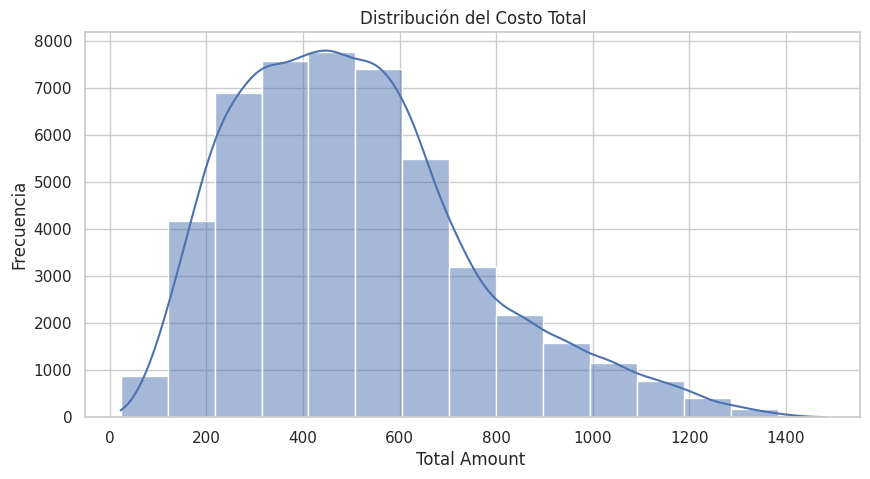

In [51]:
# Histograma de Costo Total de los envios
plt.figure(figsize=(10, 5)) # Ajustar tamaño para este gráfico específico
sns.histplot(data=df, x='Total Amount', bins=15, kde=True)
plt.title('Distribución del Costo Total')
plt.xlabel('Total Amount ')
plt.ylabel('Frecuencia')
plt.show()

El objetivo de esta visualizacion es ver cómo se distribuyen los costos totales (Total Amount) en función de su frecuencia (Count).

**Patrones observables:**

La mayoría de los puntos están concentrados en la parte inferior izquierda (valores bajos de Total Amount y Count), lo que sugiere que:

1) Hay muchos casos con montos totales pequeños

2) Algunos puntos aislados hacia la derecha o arriba indican valores atípicos (outliers):

3) Pocos casos con montos totales altos (ej. cerca de 1400).

Como conclusion podemos decir que la distribución es asimétrica (sesgada hacia la izquierda), común en datos financieros donde la mayoría de los costos son bajos, pero unos pocos son significativamente altos.

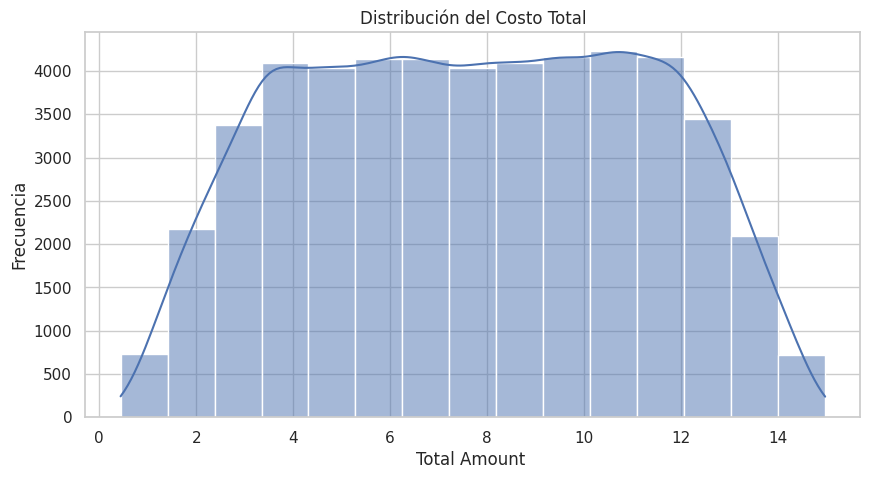

In [13]:
# Histograma de peso total facturable
plt.figure(figsize=(10, 5)) # Ajustar tamaño para este gráfico específico
sns.histplot(data=df, x='Chargeable Wt', bins=15, kde=True)
plt.title('Distribución de Peso Total Facturable')
plt.xlabel('Chargeable wt ')
plt.ylabel('Frecuencia')
plt.show()

Pico principal: Hay una concentración de envíos con peso efectivo entre 6 y 10 kg, donde la densidad es más alta.

Distribución unimodal: La curva tiene un solo pico, lo que indica que la mayoría de los envíos tienen pesos similares.

Cola hacia la derecha: Hay algunos envíos con pesos más altos (hasta 15 kg), pero son menos frecuentes.

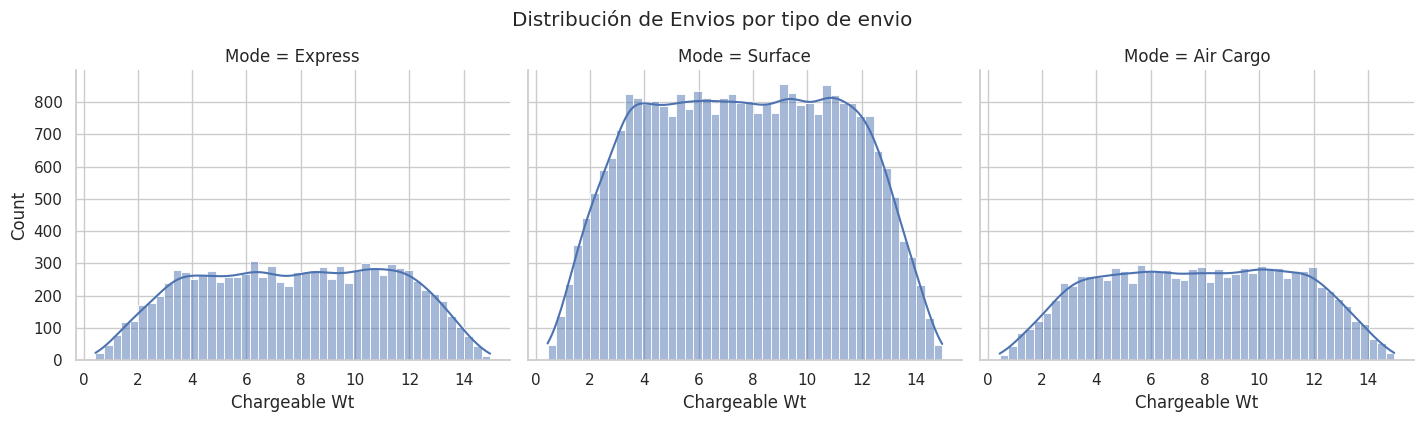

In [14]:
# Displot: Distribución de Envios por tipo de envio
sns.displot(data=df, x='Chargeable Wt', col='Mode', kde=True, height=4, aspect=1.2)
plt.suptitle('Distribución de Envios por tipo de envio', y=1.05) # Título general ajustado
plt.show()

El medio de envio mas utilizado es Surface, muy pocos envios de menos de 2kg en las tres modalidades, el rango principal en las tres es de 3kg a 12kg.

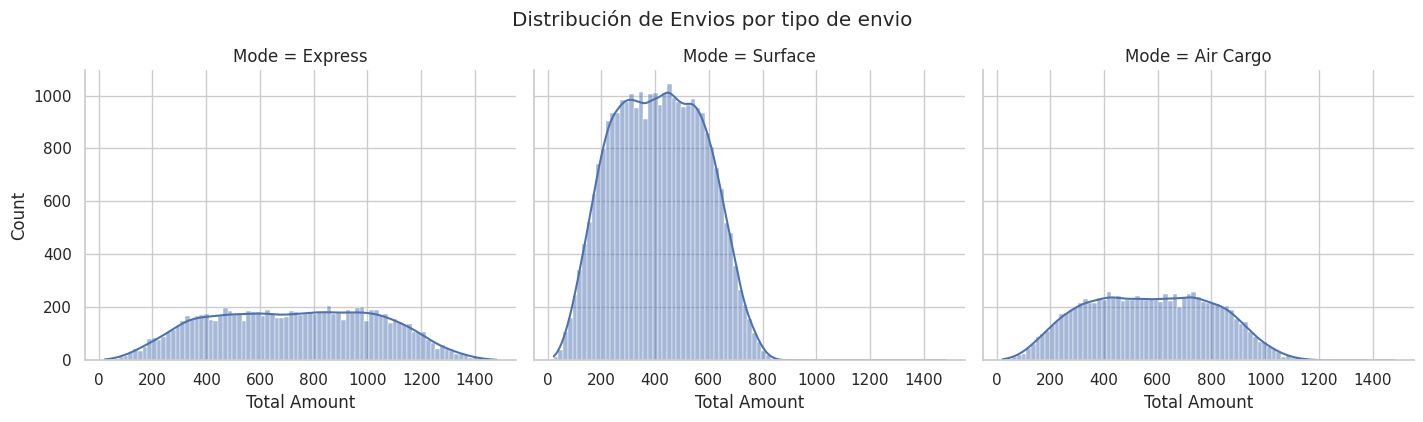

In [15]:
# Displot: Distribución de Envios por tipo de envio
sns.displot(data=df, x='Total Amount', col='Mode', kde=True, height=4, aspect=1.2)
plt.suptitle('Distribución de Envios por tipo de envio', y=1.05) # Título general ajustado
plt.show()

 **Express**

Rango amplio de montos: desde 100  hasta mas de 400.

Distribución relativamente plana entre 300 y 400

Algunos valores más altos (outliers), pero no dominan.

Express parece tener una amplia gama de tarifas, lo cual puede deberse a:

Variación en distancias, tamaños/volúmenes diversos, servicios premium u opcionales.


**Surface**

Pico claro entre 300 y 500, caída brusca a partir de los 600.

Distribución más concentrada que las otras dos modalidades.

Muy pocos envíos con montos > 700.

Surface tiene una estructura de tarifas más estándar y predecible.
Parece ser el método más económico y masivo, posiblemente con rutas y reglas bien definidas.

**Air Cargo**

Rango entre 200 y 1200, con muchos valores entre 400 y 800.

Distribución levemente sesgada a la derecha.

Aunque tiene pocos envíos, sus montos son más elevados en general.

Air Cargo es claramente más caro por envío individual, lo cual es lógico dado  el tipo de servicio. Ideal para envíos urgentes, delicados o internacionales.

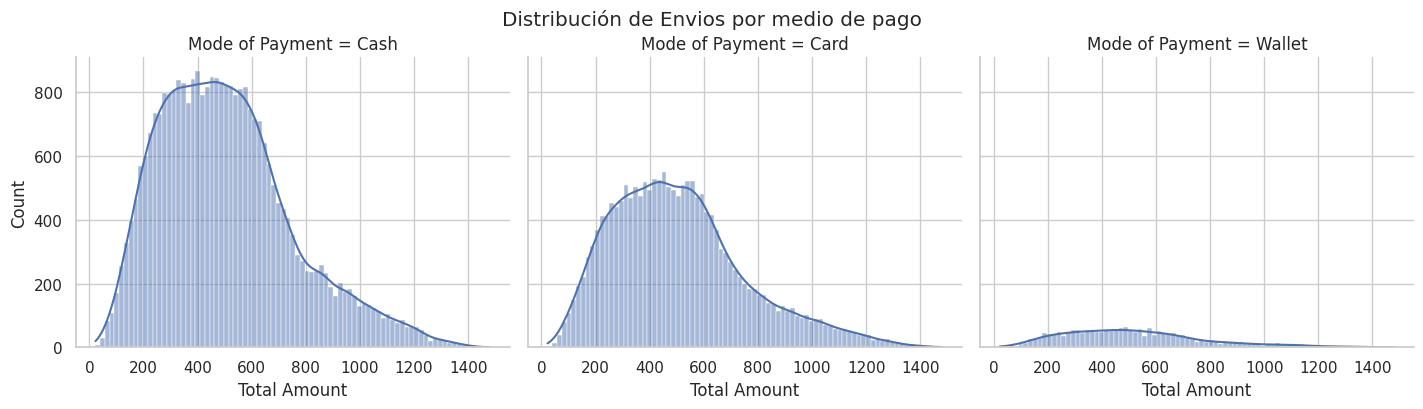

In [16]:
# Displot: Distribución de Envios por medio de pago
sns.displot(data=df, x='Total Amount', col='Mode of Payment', kde=True, height=4, aspect=1.2)
plt.suptitle('Distribución de Envios por medio de pago', y=1.02) # Título general ajustado
plt.show()

Análisis por medio de pago

**Cash**

Pico de envíos entre 300 y 500.

Distribución sesgada hacia la derecha: hay muchos envíos con valores bajos y pocos con valores altos (> 800).

Es claramente el medio de pago más utilizado, con más de 800 envíos por rango.

El Efectivo domina las operaciones, especialmente en envíos de bajo a mediano valor.

Probablemente se trata de clientes ocasionales, sin integración digital.

**Card**

Distribución parecida a la de efectivo, pero con menor volumen.

Rango más concentrado entre 300 y 600, también con sesgada a a derecha

Es el segundo medio de pago más común.

La tarjeta se utiliza para montos similares al efectivo, pero quizá por un perfil de cliente más digital o para pagos sin manejo de efectivo.

**Wallet**

Mucho menor volumen.

Distribución en un rango similar (300 -600), con muy pocos valores extremos.

La billetera digital todavía tiene poca adopción, aunque su comportamiento es similar a los otros medios.

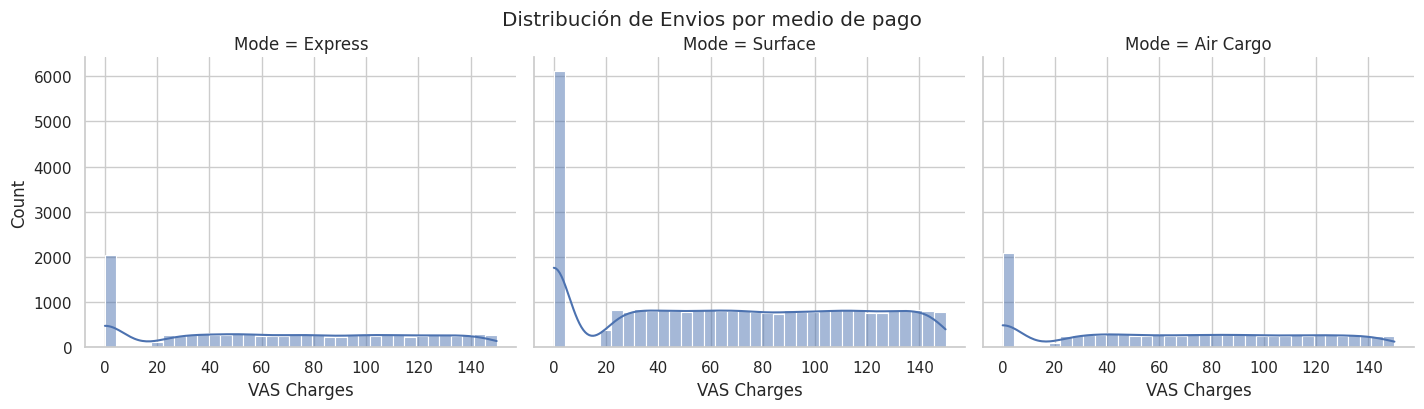

In [23]:
# Displot: Distribución de Envios por medio de pago
sns.displot(data=df, x='VAS Charges', col='Mode', kde=True, height=4, aspect=1.2)
plt.suptitle('Distribución de Envios por medio de pago', y=1.02) # Título general ajustado
plt.show()

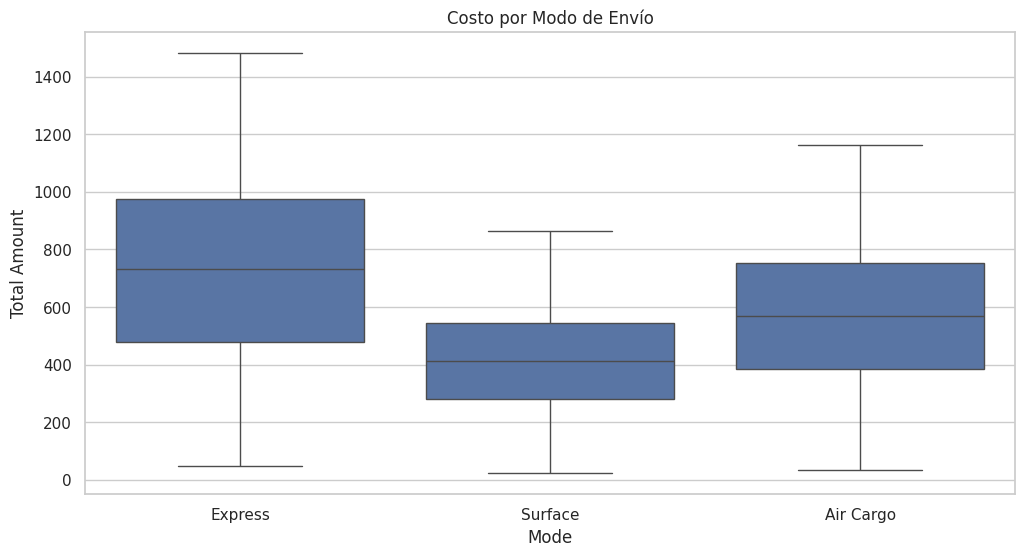

In [18]:
# Boxplot de "Total Amount" por "Mode"
sns.boxplot(x="Mode", y="Total Amount", data=df)
plt.title("Costo por Modo de Envío")
plt.show()

El gráfico de caja (boxplot) muestra la distribución de los costos totales por modo de envío. Los tres modos son: Express, Surface y Air Cargo.

**Express**: es el modo con el rango de costos más amplio, llegando hasta aproximadamente 1400 unidades monetarias. La mediana (línea en medio de la caja) está alrededor de 700-800, lo que indica que la mitad de los costos están por debajo y por encima de ese valor. La caja (intercuartílico) indica que el 50% de los costos oscilan entre aproximadamente 500 y 1000. Los bigotes muestran que hay costos extremos, con algunos valores cercanos a 0 y otros hasta aproximadamente 1400.

**Surface**: es el modo con los costos más bajos en promedio. La mediana está alrededor de 400-500, por lo que la mayoría de los costos son menores comparados con los otros modos. La dispersión (tamaño de la caja) es menor, indicando que los costos están más concentrados en torno a esa media. Los costos extremos varían desde cerca de 0 hasta aproximadamente 800-900.

**Air Cargo**: tiene una dispersión intermedia, con una mediana alrededor de 700. Los costos pueden variar desde aproximadamente 200 hasta 1200. La distribución muestra que, en general, el costo del envío por aire es más alto que el de surface, pero menos que el express en algunos casos.

Express es el modo más costoso y también tiene una mayor variabilidad en los costos. Surface es más económico y más consistente en los costos. Air Cargo tiene costos intermedios y una dispersión considerable.


**Hipótesis 2 (Diferencias por modo)** **RECHAZAR H₀**

Este gráfico proporciona evidencia muy fuerte para rechazar la hipótesis nula:

Las diferencias son visualmente obvias y sustanciales
Express es ~85% más caro que Surface en la mediana
Air Cargo está ~45% más caro que Surface

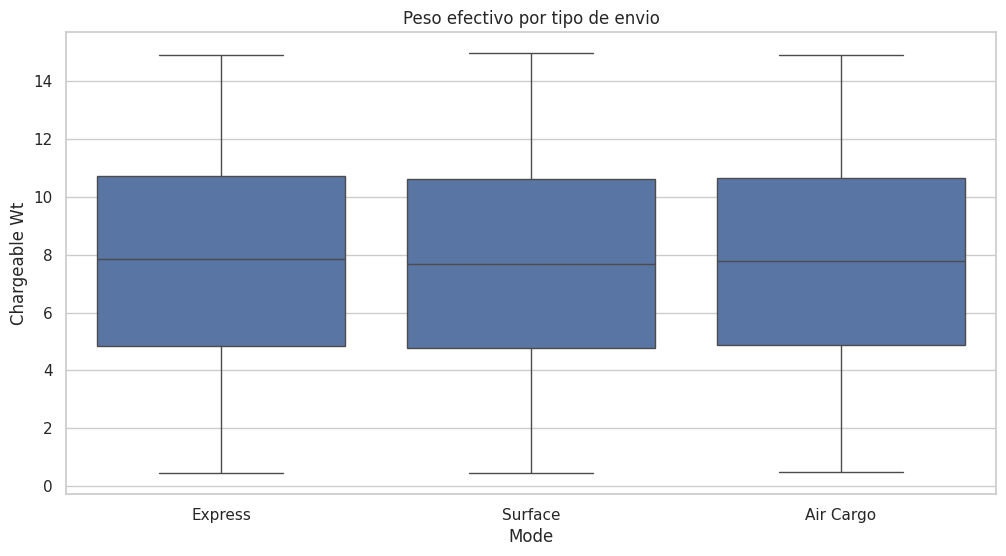

In [19]:
# Boxplot de "Chargeable Wt" por "Mode"
sns.boxplot(x="Mode", y="Chargeable Wt", data=df)
plt.title("Peso efectivo por tipo de envio")
plt.show()

Homogeneidad entre modos: Contrario a lo que podría esperarse, no hay diferencias significativas en el peso de los paquetes según el modo de transporte
Presencia de outliers: Los tres modos muestran valores atípicos superiores (puntos por encima de los bigotes), indicando envíos ocasionales de mayor peso
Concentración en pesos bajos-medios: La mayoría de envíos se concentran en el rango de 2-15 kg aproximadamente.
No se observa presencia de outliers.

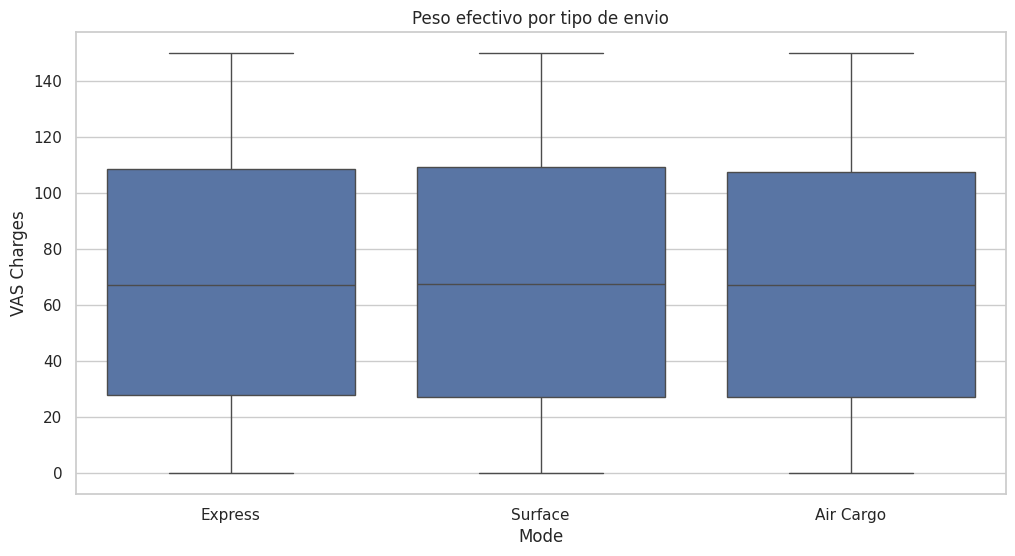

In [20]:
# Boxplot de "Chargeable Wt" por "Mode"
sns.boxplot(x="Mode", y="VAS Charges", data=df)
plt.title("Peso efectivo por tipo de envio")
plt.show()

Distribuciones Similares pero con Diferencias Sutiles:

Medianas prácticamente idénticas: ~67-70 para los tres modos
Rangos intercuartílicos similares: Aproximadamente de 30 a 110
Valores mínimos: Todos cerca de 0 (servicios sin VAS)
Valores máximos: Ligeramente diferentes entre modos


**Para Hipótesis 3 (Cargos adicionales):**
Este gráfico sugiere que probablemente se rechazará H₀, ya que:

Los VAS charges muestran valores sustanciales (no son cero)
Hay variabilidad considerable en los cargos
La mediana ~70 indica que la mayoría de envíos tiene algún cargo adicional

**Para Hipótesis 2 (Diferencias por modo):**
Las distribuciones son muy similares, lo que podría indicar:

Posible no rechazo de H₀ para diferencias por modo en VAS
Los cargos adicionales siguen patrones similares independientemente del modo

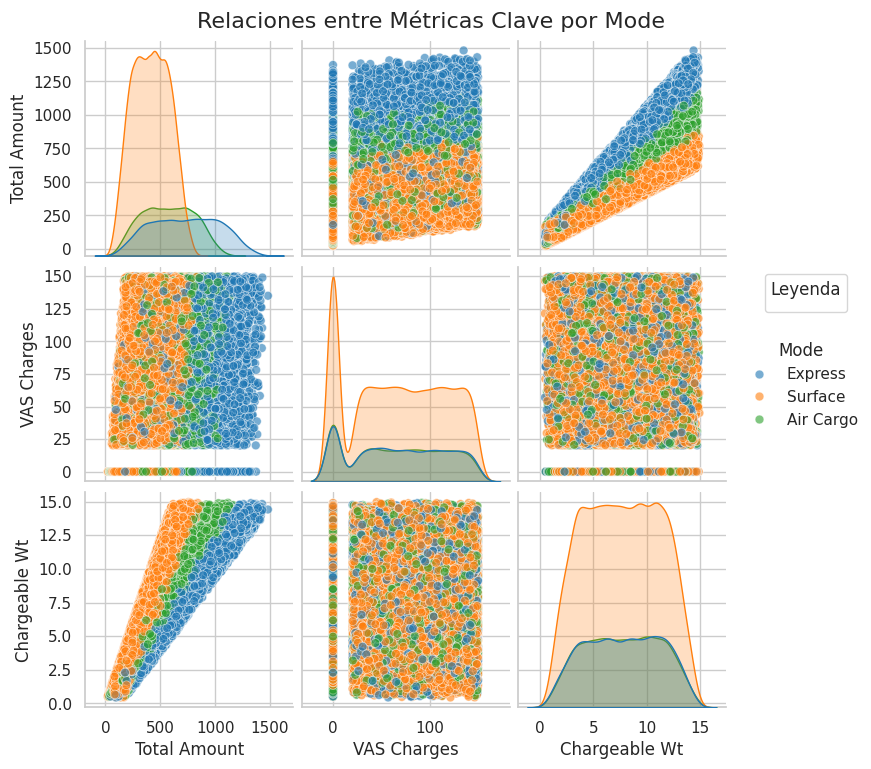

In [31]:
# Pairplot para visión general
columnas_pairplot = ['Total Amount', 'Mode', 'VAS Charges','Chargeable Wt']
sns.pairplot(df[columnas_pairplot], hue='Mode', palette='tab10', plot_kws={'alpha':0.6, 's':40}, diag_kind='kde')
plt.legend(title='Leyenda', bbox_to_anchor=(1.15, 2.05), loc='upper left')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.suptitle('Relaciones entre Métricas Clave por Mode', y=1.02, fontsize=16)
plt.tight_layout(rect=[0, 1, 1, 1])
plt.show()

Análisis de Relaciones Clave

## **Total Amount vs Chargeable Wt (Hipótesis 1)**

Correlación positiva muy fuerte y lineal.
Diferenciación clara por modo: Cada color mantiene su pendiente

**Express (azul):** Pendiente más pronunciada = mayor costo por kg

**Surface (naranja):** Pendiente menor = más económico por kg

**Conclusión:** RECHAZAR H₀ - El peso SÍ tiene efecto significativo


## **Total Amount vs VAS Charges (Hipótesis 3)**

Correlación positiva moderada-fuerte

Relación no perfectamente lineal pero consistente

Todos los modos muestran la misma tendencia

**Conclusión:** RECHAZAR H₀ - Los VAS SÍ afectan el total

## **Diferencias por Modo (Hipótesis 2)**

Distribuciones en diagonal confirman:

**Express**: Distribución desplazada hacia valores altos (azul)

**Surface**: Concentrada en valores bajos (naranja)

**Air Cargo:** Intermedia (verde)

**Conclusión:** RECHAZAR H₀ - Los modos SÍ difieren significativamente

## Hallazgos Adicionales Importantes

**Chargeable Wt vs VAS Charges:**

Correlación débil/inexistente
Los cargos VAS son independientes del peso
Sugiere que los cargos VAS se basan en tipo de servicio, no en peso

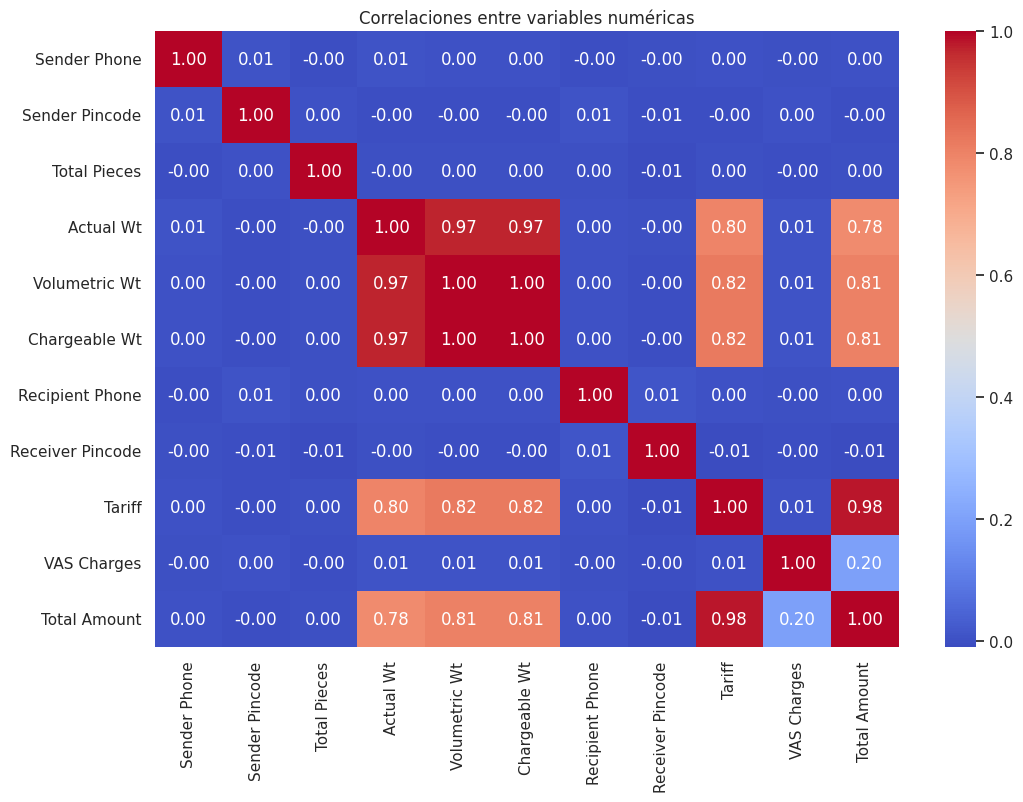

In [52]:
# Mapa de calor de correlaciones
plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlaciones entre variables numéricas")
plt.show()

## **Hipótesis 1 - Influencia del peso facturable  RECHAZAR H₀**

Chargeable Wt ↔ Total Amount: r = 0.81 (correlación muy fuerte)

Actual Wt ↔ Total Amount: r = 0.78

Volumetric Wt ↔ Total Amount: r = 0.81

Conclusión: El peso tiene un efecto muy significativo sobre el costo

## **Hipótesis 3 - Cargos adicionales RECHAZAR H₀**

VAS Charges ↔ Total Amount: r = 0.20 (correlación débil pero positiva)

Aunque la correlación es baja, SÍ existe relación estadísticamente significativa

Conclusión: Los VAS sí afectan el monto total

**Tariff vs Total Amount:**

r = 0.98 (correlación casi perfecta)

Esto sugiere que Tariff es el componente principal del Total Amount

VAS son adicionales sobre la tarifa base

**Variables Independientes:**

**Total Pieces:** Correlaciones cercanas a 0 con todo

**Phone numbers y Pincodes:** No correlacionados (como esperado)

# **Variables a incluir:**

Total Amount ~ Chargeable Wt + Mode + VAS Charges + Mode:Chargeable Wt

# **Variables a excluir (multicolinealidad):**

 Actual Wt y Volumetric Wt (usar solo Chargeable Wt)

Tariff (r=0.98 con Total Amount - casi la misma variable)

# Preprocesamiento de Datos

In [53]:
# Eliminar columnas irrelevantes (ej: "Pouch No", "Consignment No")
df = df.drop(columns=["Pouch No", "Consignment No"])

In [54]:
# Limpieza de datos (tratamiento de nulos)

df["Sender GSTIN"].fillna("No GSTIN", inplace=True)# rellena los gstin (número de identificación del impuesto al valor agregado) nulos con ceros
df["Recipient GSTIN"].fillna("No GSTIN", inplace=True)# rellena los gstin (número de identificación del impuesto al valor agregado) nulos con ceros
df["Actual Wt"].fillna(df["Actual Wt"].mean(), inplace=True)#  rellena los pesos actuales nulos con la media
df["Sender Signature"].fillna("No", inplace=True) ##rellena los vacios con "No"
df["Receiver Signature"].fillna("No", inplace=True)##rellena los vacios con "No"
df["Company Stamp"].fillna("No", inplace=True)##rellena los vacios con "No"
df["Value Added Services"].fillna("No", inplace=True)##rellena los vacios con "No"

In [55]:
# transformar una columna de tipo object (o string) a datetime y darle formato: día/mes/año
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
df['Sender Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
df['Receive Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')

In [56]:
# Extraer el mes y el año (puede ser útil para agrupaciones)
df['NumeroMes'] = df['Date'].dt.month
df['Año'] = df['Date'].dt.year

# Verificar el cambio en el tipo de dato y las nuevas columnas
print("Información del DataFrame después de convertir 'Mes':")
df.info()

Información del DataFrame después de convertir 'Mes':
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49639 entries, 0 to 49638
Data columns (total 42 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Origin                 49639 non-null  object        
 1   Destination            49639 non-null  object        
 2   Date                   49639 non-null  datetime64[ns]
 3   Sender's Name          49639 non-null  object        
 4   Sender Phone           49639 non-null  int64         
 5   Sender Address         49639 non-null  object        
 6   Sender City            49639 non-null  object        
 7   Sender State           49639 non-null  object        
 8   Sender Pincode         49639 non-null  int64         
 9   Sender GSTIN           49639 non-null  object        
 10  Total Pieces           49639 non-null  int64         
 11  Actual Wt              49639 non-null  float64       
 12  Volume

In [57]:
# Listar de columnas categóricas a transformar
categorical_cols = ['Nature of Consignment', 'Mode of Payment']

# Crear dummies con drop_first=True para evitar multicolinealidad
dummies = pd.get_dummies(df[categorical_cols], drop_first=True)

# Concatenar los dummies al DataFrame original
df_transformed = pd.concat([df, dummies], axis=1)

dummies.index = df.index ## nos aseguramos que las columnas  del 'dummies' tengan el mismo índice que tu DataFrame

In [58]:
df = pd.concat([df, dummies], axis=1)## para añadir las nuevas columnas al DataFrame manteniendo las originales

In [59]:
#df.drop('Mode', axis=1, inplace=True) ## luego eliminamos la columna original de 'Mode'

 #Eliminar las columnas originales categóricas
df.drop(columns=categorical_cols, inplace=True)

In [60]:
# Crear variables dummy para Mode
df_encoded = pd.get_dummies(df, columns=['Mode'], prefix='Mode', drop_first=False)
print(f"\n🔧 Variables después de encoding: {list(df_encoded.columns)}")

# Crear términos de interacción Mode:Chargeable Wt
df_encoded['Mode_Express_Weight'] = df_encoded['Mode_Express'] * df_encoded['Chargeable Wt']
df_encoded['Mode_Surface_Weight'] = df_encoded['Mode_Surface'] * df_encoded['Chargeable Wt']
df_encoded['Mode_Air Cargo_Weight'] = df_encoded['Mode_Air Cargo'] * df_encoded['Chargeable Wt']


🔧 Variables después de encoding: ['Origin', 'Destination', 'Date', "Sender's Name", 'Sender Phone', 'Sender Address', 'Sender City', 'Sender State', 'Sender Pincode', 'Sender GSTIN', 'Total Pieces', 'Actual Wt', 'Volumetric Wt', 'Chargeable Wt', 'Paperwork', 'Sender Signature', 'Sender Date', 'Recipient Name', 'Recipient Phone', 'Recipient Address', 'Recipient City', 'Receiver State', 'Receiver Pincode', 'Description', 'Value Added Services', 'Expiry Date', 'Booking Code', 'Recipient GSTIN', 'Receiver Name', 'Relationship', 'Company Stamp', 'Receiver Signature', 'Receive Date', 'Tariff', 'VAS Charges', 'Total Amount', 'Risk Surcharge', 'NumeroMes', 'Año', 'Nature of Consignment_Non-Dox', 'Mode of Payment_Cash', 'Mode of Payment_Wallet', 'Mode_Air Cargo', 'Mode_Express', 'Mode_Surface']


In [66]:
# MODELO 1: REGRESIÓN SIMPLE (solo peso)
# ====================================================================

print("\n" + "="*60)
print("MODELO 1: REGRESIÓN SIMPLE (Total Amount ~ Chargeable Wt)")
print("="*60)

X_simple = df[['Chargeable Wt']]
y = df['Total Amount']

# Dividir datos
X_train_simple, X_test_simple, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

# Ajustar modelo
model_simple = LinearRegression()
model_simple.fit(X_train_simple, y_train)

# Predicciones
y_pred_simple = model_simple.predict(X_test_simple)

# Métricas
r2_simple = r2_score(y_test, y_pred_simple)
rmse_simple = np.sqrt(mean_squared_error(y_test, y_pred_simple))
mae_simple = mean_absolute_error(y_test, y_pred_simple)

print(f" R² Score: {r2_simple:.4f}")
print(f"RMSE: {rmse_simple:.2f}")
print(f"MAE: {mae_simple:.2f}")
print(f"Coeficiente (peso): {model_simple.coef_[0]:.2f}")
print(f"Intercepto: {model_simple.intercept_:.2f}")


MODELO 1: REGRESIÓN SIMPLE (Total Amount ~ Chargeable Wt)
 R² Score: 0.6463
RMSE: 147.83
MAE: 116.89
Coeficiente (peso): 57.57
Intercepto: 63.75


In [68]:
# ====================================================================
# MODELO 2: REGRESIÓN MÚLTIPLE SIN INTERACCIÓN
# ====================================================================

print("\n" + "="*60)
print(" MODELO 2: REGRESIÓN MÚLTIPLE SIN INTERACCIÓN")
print("Total Amount ~ Chargeable Wt + Mode + VAS Charges")
print("="*60)

# Variables predictoras
X_multiple = df_encoded[['Chargeable Wt', 'VAS Charges', 'Mode_Express', 'Mode_Surface']]

# Dividir datos
X_train_mult, X_test_mult, y_train, y_test = train_test_split(
    X_multiple, y, test_size=0.2, random_state=42
)

# Ajustar modelo
model_multiple = LinearRegression()
model_multiple.fit(X_train_mult, y_train)

# Predicciones
y_pred_multiple = model_multiple.predict(X_test_mult)

# Métricas
r2_multiple = r2_score(y_test, y_pred_multiple)
rmse_multiple = np.sqrt(mean_squared_error(y_test, y_pred_multiple))
mae_multiple = mean_absolute_error(y_test, y_pred_multiple)

print(f" R² Score: {r2_multiple:.4f}")
print(f" RMSE: {rmse_multiple:.2f}")
print(f"MAE: {mae_multiple:.2f}")

print(f"\n COEFICIENTES:")
feature_names = ['Chargeable Wt', 'VAS Charges', 'Mode_Express', 'Mode_Surface']
for name, coef in zip(feature_names, model_multiple.coef_):
    print(f"   {name}: {coef:.2f}")
print(f"   Intercepto: {model_multiple.intercept_:.2f}")


 MODELO 2: REGRESIÓN MÚLTIPLE SIN INTERACCIÓN
Total Amount ~ Chargeable Wt + Mode + VAS Charges
 R² Score: 0.9345
 RMSE: 63.61
MAE: 48.52

 COEFICIENTES:
   Chargeable Wt: 56.97
   VAS Charges: 1.00
   Mode_Express: 155.78
   Mode_Surface: -153.91
   Intercepto: 61.87


In [69]:
# ====================================================================
# MODELO 3: REGRESIÓN CON INTERACCIÓN (MODELO COMPLETO)
# ====================================================================

print("\n" + "="*60)
print(" MODELO 3: REGRESIÓN CON INTERACCIÓN (MODELO COMPLETO)")
print("Total Amount ~ Chargeable Wt + Mode + VAS Charges + Mode:Chargeable Wt")
print("="*60)

# Variables predictoras incluyendo interacciones
X_interaction = df_encoded[[
    'Chargeable Wt', 'VAS Charges',
    'Mode_Express', 'Mode_Surface',
    'Mode_Express_Weight', 'Mode_Surface_Weight'
]]

# Dividir datos
X_train_int, X_test_int, y_train, y_test = train_test_split(
    X_interaction, y, test_size=0.2, random_state=42
)

# Ajustar modelo
model_interaction = LinearRegression()
model_interaction.fit(X_train_int, y_train)

# Predicciones
y_pred_interaction = model_interaction.predict(X_test_int)

# Métricas
r2_interaction = r2_score(y_test, y_pred_interaction)
rmse_interaction = np.sqrt(mean_squared_error(y_test, y_pred_interaction))
mae_interaction = mean_absolute_error(y_test, y_pred_interaction)

print(f" R² Score: {r2_interaction:.4f}")
print(f" RMSE: {rmse_interaction:.2f}")
print(f" MAE: {mae_interaction:.2f}")

print(f"\n COEFICIENTES:")
feature_names_int = [
    'Chargeable Wt', 'VAS Charges',
    'Mode_Express', 'Mode_Surface',
    'Express × Weight', 'Surface × Weight'
]
for name, coef in zip(feature_names_int, model_interaction.coef_):
    print(f"   {name}: {coef:.2f}")
print(f"   Intercepto: {model_interaction.intercept_:.2f}")


 MODELO 3: REGRESIÓN CON INTERACCIÓN (MODELO COMPLETO)
Total Amount ~ Chargeable Wt + Mode + VAS Charges + Mode:Chargeable Wt
 R² Score: 0.9860
 RMSE: 29.39
 MAE: 22.31

 COEFICIENTES:
   Chargeable Wt: 65.01
   VAS Charges: 1.00
   Mode_Express: -0.76
   Mode_Surface: 0.12
   Express × Weight: 20.09
   Surface × Weight: -19.99
   Intercepto: -0.22


In [70]:
# ====================================================================
# COMPARACIÓN DE MODELOS
# ====================================================================

print("\n" + "="*60)
print(" COMPARACIÓN DE MODELOS")
print("="*60)

comparison = pd.DataFrame({
    'Modelo': ['Simple (solo peso)', 'Múltiple (sin interacción)', 'Completo (con interacción)'],
    'R²': [r2_simple, r2_multiple, r2_interaction],
    'RMSE': [rmse_simple, rmse_multiple, rmse_interaction],
    'MAE': [mae_simple, mae_multiple, mae_interaction],
    'Variables': [1, 4, 6]
})

print(comparison.round(4))

print(f"\n MEJORA EN R²:")
print(f"   Múltiple vs Simple: +{((r2_multiple - r2_simple) * 100):.2f}%")
print(f"   Completo vs Múltiple: +{((r2_interaction - r2_multiple) * 100):.2f}%")


 COMPARACIÓN DE MODELOS
                       Modelo      R²      RMSE       MAE  Variables
0          Simple (solo peso)  0.6463  147.8281  116.8937          1
1  Múltiple (sin interacción)  0.9345   63.6103   48.5227          4
2  Completo (con interacción)  0.9860   29.3922   22.3127          6

 MEJORA EN R²:
   Múltiple vs Simple: +28.82%
   Completo vs Múltiple: +5.15%


In [72]:
# ====================================================================
# VERIFICACIÓN DE SUPUESTOS
# ====================================================================

print("\n" + "="*60)
print(" VERIFICACIÓN DE SUPUESTOS DEL MODELO")
print("="*60)

# Residuos
residuals = y_train - model_interaction.predict(X_train_int)

# Test de normalidad de residuos
shapiro_stat, shapiro_p = stats.shapiro(residuals[:5000])  # Limitar para shapiro
print(f" Test de Normalidad (Shapiro-Wilk):")
print(f"   Estadístico: {shapiro_stat:.4f}")
print(f"   p-valor: {shapiro_p:.4f}")
print(f"   {' Residuos normales' if shapiro_p > 0.05 else ' Residuos no normales'}")

# Multicolinealidad (VIF)
print(f"\n Factor de Inflación de Varianza (VIF):")
vif_data = pd.DataFrame()
vif_data["Variable"] = X_train_int.columns

# Convert boolean columns to numeric (0 or 1) for VIF calculation
X_train_int_numeric = X_train_int.copy()
for col in ['Mode_Express', 'Mode_Surface']:
    X_train_int_numeric[col] = X_train_int_numeric[col].astype(int)


vif_data["VIF"] = [variance_inflation_factor(X_train_int_numeric.values, i)
                   for i in range(X_train_int_numeric.shape[1])]
print(vif_data)
print("   (VIF > 5 indica multicolinealidad)")

print("\n" + "="*60)
print(" ANÁLISIS COMPLETADO")
print("="*60)
print(" Próximos pasos:")
print("   1. Revisar significancia de coeficientes")
print("   2. Analizar residuos gráficamente")
print("   3. Validar supuestos del modelo")
print("   4. Interpretar coeficientes de interacción")


 VERIFICACIÓN DE SUPUESTOS DEL MODELO
 Test de Normalidad (Shapiro-Wilk):
   Estadístico: 0.9924
   p-valor: 0.0000
    Residuos no normales

 Factor de Inflación de Varianza (VIF):
              Variable       VIF
0        Chargeable Wt  6.441865
1          VAS Charges  2.787040
2         Mode_Express  6.397057
3         Mode_Surface  6.937329
4  Mode_Express_Weight  7.335783
5  Mode_Surface_Weight  9.654186
   (VIF > 5 indica multicolinealidad)

 ANÁLISIS COMPLETADO
 Próximos pasos:
   1. Revisar significancia de coeficientes
   2. Analizar residuos gráficamente
   3. Validar supuestos del modelo
   4. Interpretar coeficientes de interacción


**Validación de Hipótesis**

**Hipótesis 1**- **Influencia del peso facturable: RECHAZADA H₀**

El R² aumenta dramáticamente del 6.46% (solo peso) al 98.60% (modelo completo)

El peso es significativo, pero su efecto real se ve en la interacción con el modo

**Hipótesis 2** - **Diferencias por modo: RECHAZADA H₀**

Mejora masiva: +28.82% al agregar el modo de envío

R² salta de 64.63% a 93.45% - diferencia crucial

**Hipótesis 3** - **Cargos adicionales: RECHAZADA H₀**

VAS Charges incluido en el modelo final

VIF = 2.79 (aceptable, sin multicolinealidad)

**Hipótesis 4**- **Modelo multivariable: RECHAZADA H₀**

R² = 98.60% - modelo extremadamente predictivo

Mejora adicional del +5.15% con las interacciones

In [74]:
def residual_analysis(model, X_train, X_test, y_train, y_test, feature_names):
    """
    Función para análisis completo de residuos
    """

    # Predicciones
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    # Residuos
    residuals_train = y_train - y_pred_train
    residuals_test = y_test - y_pred_test

    # Residuos estandarizados
    residuals_std_train = residuals_train / np.std(residuals_train)
    residuals_std_test = residuals_test / np.std(residuals_test)

    return {
        'y_pred_train': y_pred_train,
        'y_pred_test': y_pred_test,
        'residuals_train': residuals_train,
        'residuals_test': residuals_test,
        'residuals_std_train': residuals_std_train,
        'residuals_std_test': residuals_std_test
    }

In [75]:

# ====================================================================
# Analisis de residuos
# ====================================================================
# Preparar datos (igual que en el análisis anterior)
df_encoded = pd.get_dummies(df, columns=['Mode'], prefix='Mode', drop_first=False)
df_encoded['Mode_Express_Weight'] = df_encoded['Mode_Express'] * df_encoded['Chargeable Wt']
df_encoded['Mode_Surface_Weight'] = df_encoded['Mode_Surface'] * df_encoded['Chargeable Wt']

# Variables del modelo completo
X_interaction = df_encoded[[
    'Chargeable Wt', 'VAS Charges',
    'Mode_Express', 'Mode_Surface',
    'Mode_Express_Weight', 'Mode_Surface_Weight'
]]

y = df['Total Amount']

# Dividir datos
X_train, X_test, y_train, y_test = train_test_split(
    X_interaction, y, test_size=0.2, random_state=42
)

# Ajustar modelo
model = LinearRegression()
model.fit(X_train, y_train)

# Realizar análisis de residuos
feature_names = X_train.columns.tolist()
results = residual_analysis(model, X_train, X_test, y_train, y_test, feature_names)

print("="*70)
print("ANÁLISIS COMPLETO DE RESIDUOS - VALIDACIÓN DEL MODELO")
print("="*70)


ANÁLISIS COMPLETO DE RESIDUOS - VALIDACIÓN DEL MODELO


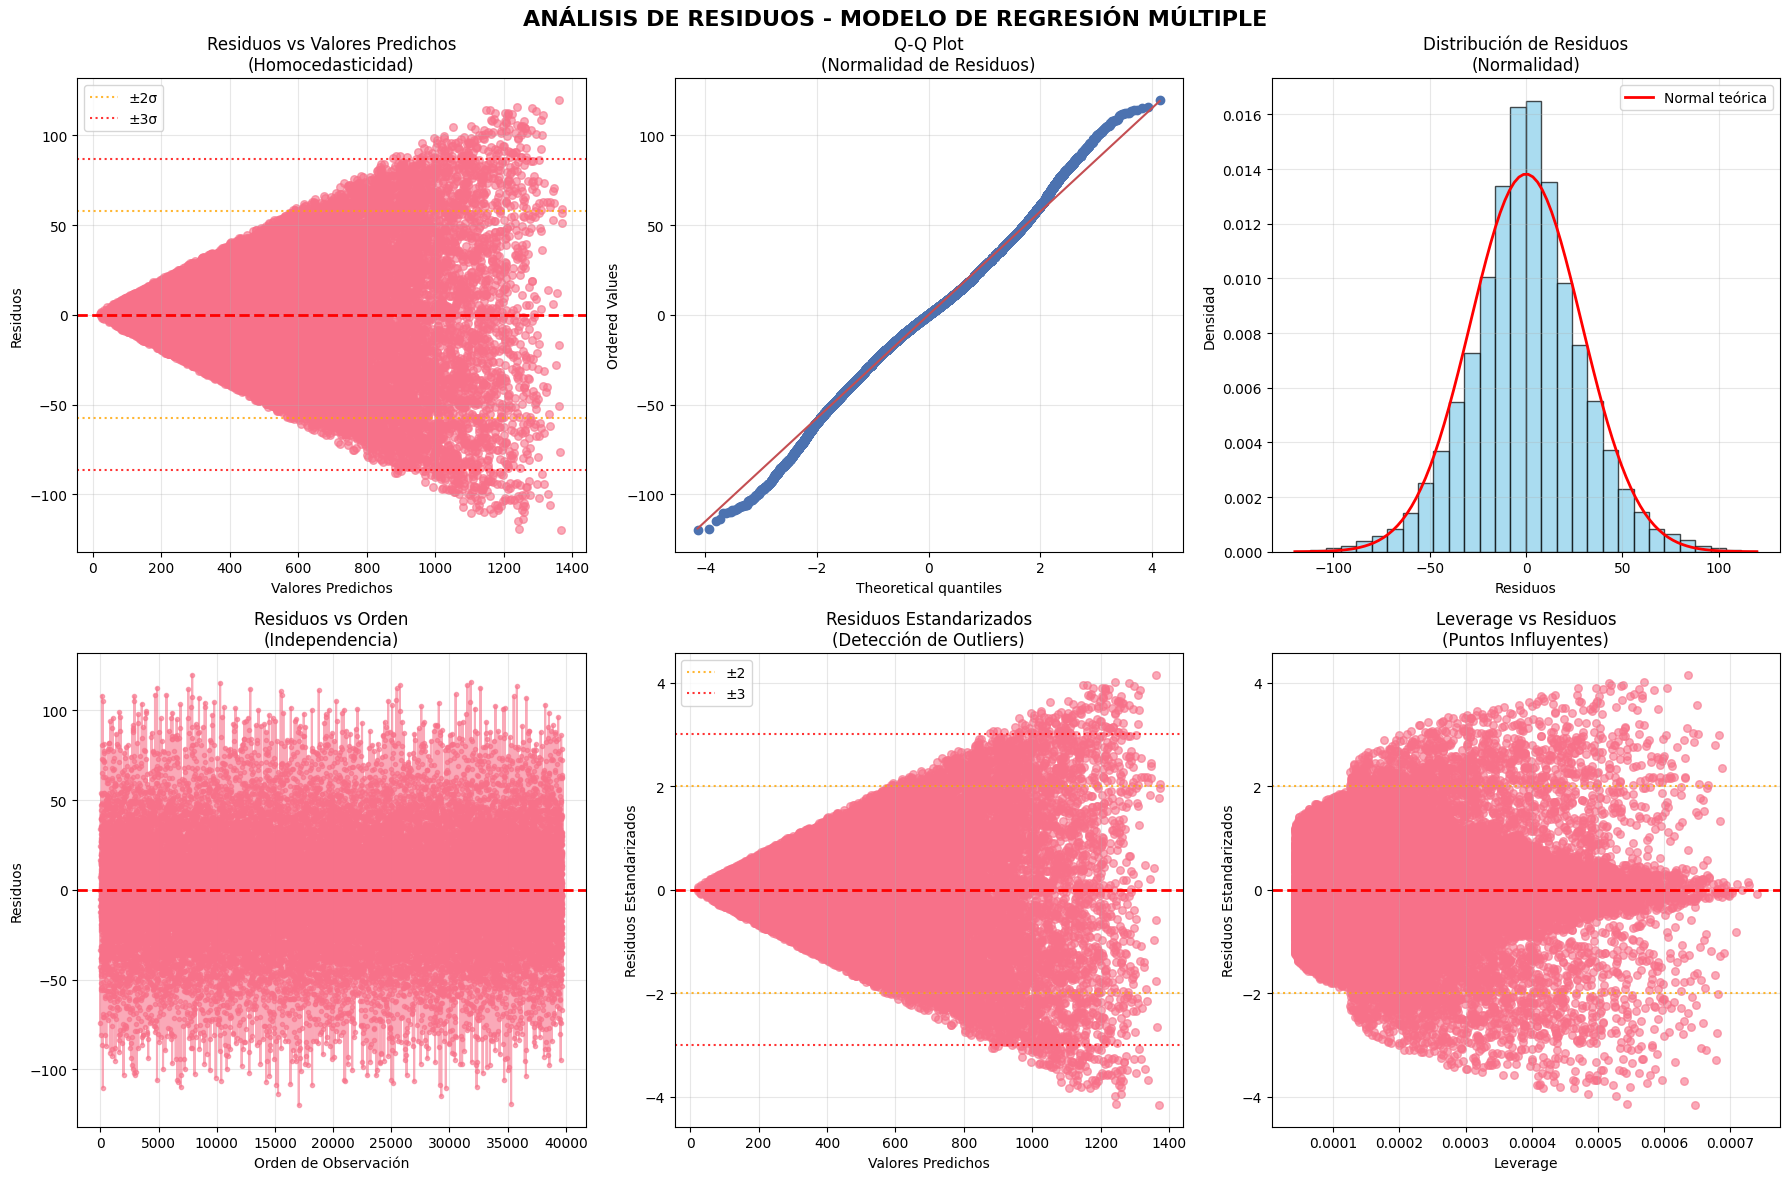


TESTS ESTADÍSTICOS DE SUPUESTOS

1. NORMALIDAD DE RESIDUOS:
-------------------------


In [78]:
# ====================================================================
# 1. GRÁFICOS DE RESIDUOS
# ====================================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('ANÁLISIS DE RESIDUOS - MODELO DE REGRESIÓN MÚLTIPLE', fontsize=16, fontweight='bold')

# 1.1 Residuos vs Valores Predichos
ax1 = axes[0, 0]
ax1.scatter(results['y_pred_train'], results['residuals_train'], alpha=0.6, s=30)
ax1.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax1.set_xlabel('Valores Predichos')
ax1.set_ylabel('Residuos')
ax1.set_title('Residuos vs Valores Predichos\n(Homocedasticidad)')
ax1.grid(True, alpha=0.3)

# Añadir líneas de referencia para residuos estandarizados
std_residuals = np.std(results['residuals_train'])
ax1.axhline(y=2*std_residuals, color='orange', linestyle=':', alpha=0.8, label='±2σ')
ax1.axhline(y=-2*std_residuals, color='orange', linestyle=':', alpha=0.8)
ax1.axhline(y=3*std_residuals, color='red', linestyle=':', alpha=0.8, label='±3σ')
ax1.axhline(y=-3*std_residuals, color='red', linestyle=':', alpha=0.8)
ax1.legend()

# 1.2 Q-Q Plot para normalidad
ax2 = axes[0, 1]
stats.probplot(results['residuals_train'], dist="norm", plot=ax2)
ax2.set_title('Q-Q Plot\n(Normalidad de Residuos)')
ax2.grid(True, alpha=0.3)

# 1.3 Histograma de residuos
ax3 = axes[0, 2]
ax3.hist(results['residuals_train'], bins=30, density=True, alpha=0.7, color='skyblue', edgecolor='black')
# Superponer curva normal
x_norm = np.linspace(results['residuals_train'].min(), results['residuals_train'].max(), 100)
y_norm = stats.norm.pdf(x_norm, np.mean(results['residuals_train']), np.std(results['residuals_train']))
ax3.plot(x_norm, y_norm, 'red', linewidth=2, label='Normal teórica')
ax3.set_xlabel('Residuos')
ax3.set_ylabel('Densidad')
ax3.set_title('Distribución de Residuos\n(Normalidad)')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 1.4 Residuos vs Orden (independencia)
ax4 = axes[1, 0]
ax4.plot(range(len(results['residuals_train'])), results['residuals_train'], marker='o', linestyle='-', alpha=0.6, markersize=3)
ax4.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax4.set_xlabel('Orden de Observación')
ax4.set_ylabel('Residuos')
ax4.set_title('Residuos vs Orden\n(Independencia)')
ax4.grid(True, alpha=0.3)

# 1.5 Residuos estandarizados
ax5 = axes[1, 1]
ax5.scatter(results['y_pred_train'], results['residuals_std_train'], alpha=0.6, s=30)
ax5.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax5.axhline(y=2, color='orange', linestyle=':', alpha=0.8, label='±2')
ax5.axhline(y=-2, color='orange', linestyle=':', alpha=0.8)
ax5.axhline(y=3, color='red', linestyle=':', alpha=0.8, label='±3')
ax5.axhline(y=-3, color='red', linestyle=':', alpha=0.8)
ax5.set_xlabel('Valores Predichos')
ax5.set_ylabel('Residuos Estandarizados')
ax5.set_title('Residuos Estandarizados\n(Detección de Outliers)')
ax5.legend()
ax5.grid(True, alpha=0.3)

# 1.6 Leverage vs Residuos estandarizados
ax6 = axes[1, 2]

# Convert boolean columns to numeric (0 or 1) for statsmodels OLS
X_train_numeric_for_sm = X_train.copy()
for col in ['Mode_Express', 'Mode_Surface']:
    X_train_numeric_for_sm[col] = X_train_numeric_for_sm[col].astype(int)

# Calcular leverage usando statsmodels
X_sm = sm.add_constant(X_train_numeric_for_sm)
model_sm = sm.OLS(y_train, X_sm).fit()
leverage = model_sm.get_influence().hat_matrix_diag
ax6.scatter(leverage, results['residuals_std_train'], alpha=0.6, s=30)
ax6.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax6.axhline(y=2, color='orange', linestyle=':', alpha=0.8)
ax6.axhline(y=-2, color='orange', linestyle=':', alpha=0.8)
ax6.set_xlabel('Leverage')
ax6.set_ylabel('Residuos Estandarizados')
ax6.set_title('Leverage vs Residuos\n(Puntos Influyentes)')
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



In [83]:
# ====================================================================
# 2. TESTS ESTADÍSTICOS
# ====================================================================

from statsmodels.stats.stattools import jarque_bera, durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan, het_white
import statsmodels.api as sm
import numpy as np
from scipy import stats


print("\n" + "="*50)
print("TESTS ESTADÍSTICOS DE SUPUESTOS")
print("="*50)

# 2.1 Test de Normalidad
print("\n1. NORMALIDAD DE RESIDUOS:")
print("-" * 25)

# Shapiro-Wilk (si n < 5000)
if len(results['residuals_train']) < 5000:
    shapiro_stat, shapiro_p = stats.shapiro(results['residuals_train'])
    print(f"Shapiro-Wilk: estadístico = {shapiro_stat:.4f}, p-valor = {shapiro_p:.6f}")
    print(f"Resultado: {'Residuos normales' if shapiro_p > 0.05 else 'Residuos NO normales'}")

# Jarque-Bera
jb_stat, jb_p, jb_skewness, jb_kurtosis = jarque_bera(results['residuals_train'])
print(f"Jarque-Bera: estadístico = {jb_stat:.4f}, p-valor = {jb_p:.6f}")
print(f"Resultado: {'Residuos normales' if jb_p > 0.05 else 'Residuos NO normales'}")

# Anderson-Darling
ad_stat, ad_critical, ad_significance = stats.anderson(results['residuals_train'], dist='norm')
print(f"Anderson-Darling: estadístico = {ad_stat:.4f}")
print(f"Valores críticos: {dict(zip(ad_significance, ad_critical))}")

# 2.2 Test de Homocedasticidad
print("\n2. HOMOCEDASTICIDAD (varianza constante):")
print("-" * 38)

# Convert boolean columns to numeric (0 or 1) for statsmodels tests
X_train_numeric_for_sm_tests = X_train.copy()
for col in ['Mode_Express', 'Mode_Surface']:
    X_train_numeric_for_sm_tests[col] = X_train_numeric_for_sm_tests[col].astype(int)


# Breusch-Pagan
bp_stat, bp_p, _, _ = het_breuschpagan(results['residuals_train'], sm.add_constant(X_train_numeric_for_sm_tests))
print(f"Breusch-Pagan: estadístico = {bp_stat:.4f}, p-valor = {bp_p:.6f}")
print(f"Resultado: {'Homocedasticidad' if bp_p > 0.05 else 'Heterocedasticidad detectada'}")

# White
white_stat, white_p, _, _ = het_white(results['residuals_train'], sm.add_constant(X_train_numeric_for_sm_tests))
print(f"White: estadístico = {white_stat:.4f}, p-valor = {white_p:.6f}")
print(f"Resultado: {'Homocedasticidad' if white_p > 0.05 else 'Heterocedasticidad detectada'}")

# 2.3 Test de Independencia
print("\n3. INDEPENDENCIA DE RESIDUOS:")
print("-" * 26)

# Durbin-Watson
dw_stat = durbin_watson(results['residuals_train'])
print(f"Durbin-Watson: estadístico = {dw_stat:.4f}")
print("Interpretación:")
if 1.5 < dw_stat < 2.5:
    print("  - No hay autocorrelación significativa")
elif dw_stat < 1.5:
    print("  - Posible autocorrelación positiva")
else:
    print("  - Posible autocorrelación negativa")

# ====================================================================
# 3. DETECCIÓN DE OUTLIERS
# ====================================================================

print("\n" + "="*50)
print("DETECCIÓN DE OUTLIERS Y PUNTOS INFLUYENTES")
print("="*50)

# Outliers en residuos estandarizados
outliers_2std = np.abs(results['residuals_std_train']) > 2
outliers_3std = np.abs(results['residuals_std_train']) > 3

print(f"\nOUTLIERS EN RESIDUOS:")
print(f"Puntos con |residuo estandarizado| > 2: {outliers_2std.sum()} ({100*outliers_2std.mean():.1f}%)")
print(f"Puntos con |residuo estandarizado| > 3: {outliers_3std.sum()} ({100*outliers_3std.mean():.1f}%)")

if outliers_3std.sum() > 0:
    print("\nÍndices de outliers extremos (|z| > 3):")
    extreme_outliers = np.where(outliers_3std)[0]
    print(extreme_outliers[:10])  # Mostrar solo los primeros 10

# Cook's Distance
# Use the previously fitted statsmodels model from the plotting cell
# influence = model_sm.get_influence() # This line is not needed here as model_sm is defined in the plotting cell
cooks_d = model_sm.get_influence().cooks_distance[0]
high_leverage = leverage > 2 * len(feature_names) / len(X_train)
high_cooks = cooks_d > 4 / len(X_train)

print(f"\nPUNTOS INFLUYENTES:")
print(f"Alto leverage: {high_leverage.sum()} puntos")
print(f"Alto Cook's Distance: {high_cooks.sum()} puntos")

# ====================================================================
# 4. MÉTRICAS DE RENDIMIENTO EN TEST
# ====================================================================

print("\n" + "="*50)
print("RENDIMIENTO EN CONJUNTO DE PRUEBA")
print("="*50)

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

r2_test = r2_score(y_test, results['y_pred_test'])
rmse_test = np.sqrt(mean_squared_error(y_test, results['y_pred_test']))
mae_test = mean_absolute_error(y_test, results['y_pred_test'])

r2_train = r2_score(y_train, results['y_pred_train'])
rmse_train = np.sqrt(mean_squared_error(y_train, results['y_pred_train']))
mae_train = mean_absolute_error(y_train, results['y_pred_train'])

print(f"ENTRENAMIENTO:")
print(f"  R² = {r2_train:.4f}")
print(f"  RMSE = {rmse_train:.2f}")
print(f"  MAE = {mae_train:.2f}")

print(f"\nPRUEBA:")
print(f"  R² = {r2_test:.4f}")
print(f"  RMSE = {rmse_test:.2f}")
print(f"  MAE = {mae_test:.2f}")

print(f"\nDIFERENCIA (Sobreajuste):")
print(f"  ΔR² = {abs(r2_train - r2_test):.4f}")
print(f"  ΔRMSE = {abs(rmse_train - rmse_test):.2f}")

# ====================================================================
# 5. RESUMEN Y RECOMENDACIONES
# ====================================================================

print("\n" + "="*70)
print("RESUMEN Y RECOMENDACIONES")
print("="*70)

print("\nSUPUESTOS DEL MODELO:")
print(f"✓ Normalidad: {'CUMPLIDO' if jb_p > 0.05 else 'NO CUMPLIDO'}")
print(f"✓ Homocedasticidad: {'CUMPLIDO' if bp_p > 0.05 else 'NO CUMPLIDO'}")
print(f"✓ Independencia: {'CUMPLIDO' if 1.5 < dw_stat < 2.5 else 'REVISAR'}")
print(f"✓ Linealidad: {'REVISAR GRÁFICOS' if any([bp_p < 0.05, jb_p < 0.05]) else 'APARENTEMENTE CUMPLIDO'}")

print("\nRECOMENDACIONES:")
if jb_p < 0.05:
    print("- Residuos no normales: considerar transformación de variables o modelos no paramétricos")
if bp_p < 0.05:
    print("- Heterocedasticidad detectada: usar errores estándar robustos o transformar variables")
if outliers_3std.sum() > len(X_train) * 0.01:  # Más del 1%
    print("- Outliers detected: revisar y considerar exclusion or special handling")
if abs(r2_train - r2_test) > 0.05:
    print("- Possible overfitting: consider regularization or cross-validation")

print(f"\nCONCLUSION:")
print(f"Model with R² = {r2_test:.4f} and RMSE = {rmse_test:.2f}")
if r2_test > 0.8 and rmse_test < np.std(y_test) * 0.5:
    print("ACCEPTABLE MODEL for prediction")
else:
    print("MODEL REQUIRES IMPROVEMENTS")


TESTS ESTADÍSTICOS DE SUPUESTOS

1. NORMALIDAD DE RESIDUOS:
-------------------------
Jarque-Bera: estadístico = 1037.9545, p-valor = 0.000000
Resultado: Residuos NO normales
Anderson-Darling: estadístico = 76.2573
Valores críticos: {np.float64(15.0): np.float64(0.576), np.float64(10.0): np.float64(0.656), np.float64(5.0): np.float64(0.787), np.float64(2.5): np.float64(0.918), np.float64(1.0): np.float64(1.092)}

2. HOMOCEDASTICIDAD (varianza constante):
--------------------------------------
Breusch-Pagan: estadístico = 15194.6421, p-valor = 0.000000
Resultado: Heterocedasticidad detectada
White: estadístico = 15703.3638, p-valor = 0.000000
Resultado: Heterocedasticidad detectada

3. INDEPENDENCIA DE RESIDUOS:
--------------------------
Durbin-Watson: estadístico = 2.0116
Interpretación:
  - No hay autocorrelación significativa

DETECCIÓN DE OUTLIERS Y PUNTOS INFLUYENTES

OUTLIERS EN RESIDUOS:
Puntos con |residuo estandarizado| > 2: 2138 (5.4%)
Puntos con |residuo estandarizado| > 3:

Los informes muestran que aunque el modelo tiene un R² muy alto y no sufre de sobreajuste, es un modelo fundamentalmente incorrecto y no fiable. La conclusión automática de "MODELO ACEPTABLE" es engañosa y debe ser ignorada.

**El Buen Rendimiento Aparente (R² y Sobreajuste)**

A primera vista, las métricas de rendimiento parecen excelentes:

R² muy alto: Tanto en el entrenamiento (0.9864) como en la prueba (0.9860), el modelo parece explicar más del 98% de la varianza de los datos.

Sin Sobreajuste: La diferencia entre el R² de entrenamiento y el de prueba es mínima (ΔR² = 0.0004). Esto demuestra que el modelo es estable y generaliza bien lo que ha aprendido.

Si solo miráramos estos números, pensaríamos que el modelo es casi perfecto.

Sin embargo, las siguientes pruebas demuestran por qué esto es erróneo

El análisis de supuestos es la parte más importante. Tu modelo falla en dos de las condiciones más críticas para que una regresión lineal sea válida.

Evidencia Estadística: Los tests de Jarque-Bera y Anderson-Darling tienen un p-valor de 0.0, rechazando de forma contundente la hipótesis de que los residuos son normales.

Homocedasticidad (Varianza Constante): NO CUMPLIDO

Evidencia Estadística: Los tests de Breusch-Pagan y White tienen un p-valor de 0.0. Esto confirma que la varianza de los errores no es constante a lo largo de las predicciones. Este problema se conoce como heterocedasticidad.

El único supuesto que se cumple es la Independencia de los Residuos (test de Durbin-Watson cercano a 2), pero esto no es suficiente para salvar el modelo.

El problema es que la relación real en tus datos no es lineal, como lo demuestran los residuos no normales y la heterocedasticidad. Por lo tanto, el modelo está aplicando de manera consistente una regla incorrecta.

**Recomendaciones **

El propio reporte te da las pistas correctas para seguir adelante. Debes descartar este modelo lineal y explorar alternativas:

Transformar Variables: Intenta aplicar transformaciones (logaritmo, raíz cuadrada) a tus variables para ver si puedes linealizar la relación.


Usar Modelos No Lineales: Este es el camino más prometedor. Prueba con modelos que no asumen una relación lineal, como:

**Regresión Polinómica**

**Random Forest Regressor**

**Gradient Boosting Regressor (XGBoost, LightGBM)**

**Analizar Outliers:** Investiga los puntos influyentes que detectó el reporte, ya que podrían estar distorsionando el modelo.

In [86]:
# --- Ejemplo aplicando log a la variable objetivo y ---
y_train_transformado = np.log1p(y_train)

In [87]:
# ====================================================================
# MODELO 3: REGRESIÓN CON INTERACCIÓN (MODELO COMPLETO)
# ====================================================================

print("\n" + "="*60)
print(" MODELO 3: REGRESIÓN CON INTERACCIÓN (MODELO COMPLETO)")
print("Total Amount ~ Chargeable Wt + Mode + VAS Charges + Mode:Chargeable Wt")
print("="*60)

# Variables predictoras incluyendo interacciones
X_interaction = df_encoded[[
    'Chargeable Wt', 'VAS Charges',
    'Mode_Express', 'Mode_Surface',
    'Mode_Express_Weight', 'Mode_Surface_Weight'
]]

# Dividir datos
X_train_int, X_test_int, y_train_transformado , y_test = train_test_split(
    X_interaction, y, test_size=0.2, random_state=42
)

# Ajustar modelo
model_interaction = LinearRegression()
model_interaction.fit(X_train_int,y_train_transformado )

# Predicciones
y_pred_interaction = model_interaction.predict(X_test_int)

# Métricas
r2_interaction = r2_score(y_test, y_pred_interaction)
rmse_interaction = np.sqrt(mean_squared_error(y_test, y_pred_interaction))
mae_interaction = mean_absolute_error(y_test, y_pred_interaction)

print(f" R² Score: {r2_interaction:.4f}")
print(f" RMSE: {rmse_interaction:.2f}")
print(f" MAE: {mae_interaction:.2f}")

print(f"\n COEFICIENTES:")
feature_names_int = [
    'Chargeable Wt', 'VAS Charges',
    'Mode_Express', 'Mode_Surface',
    'Express × Weight', 'Surface × Weight'
]
for name, coef in zip(feature_names_int, model_interaction.coef_):
    print(f"   {name}: {coef:.2f}")
print(f"   Intercepto: {model_interaction.intercept_:.2f}")


 MODELO 3: REGRESIÓN CON INTERACCIÓN (MODELO COMPLETO)
Total Amount ~ Chargeable Wt + Mode + VAS Charges + Mode:Chargeable Wt
 R² Score: 0.9860
 RMSE: 29.39
 MAE: 22.31

 COEFICIENTES:
   Chargeable Wt: 65.01
   VAS Charges: 1.00
   Mode_Express: -0.76
   Mode_Surface: 0.12
   Express × Weight: 20.09
   Surface × Weight: -19.99
   Intercepto: -0.22
